In [4]:
import sys
import os
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import uuid
import warnings
import gc

warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath(".."))

In [5]:
import pandas as pd
import numpy as np
import timesfm

from src.data_loading import load_crypto_data, preprocess_data, split_data
from src.evaluate_forecasts import evaluate_forecast_one_symbol
from models.timesfm_wrapper import TimesFMForecaster
import os
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from config.config import DATA_DIR
import time
import uuid

DATA_DIR = os.path.join('../data')
OUTPUTS_DIR = os.path.join(DATA_DIR, 'outputs')
os.makedirs(OUTPUTS_DIR, exist_ok=True)

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.11 | packaged by Anaconda, Inc. | (main, Dec 11 2024, 16:34:19) [MSC v.1929 64 bit (AMD64)].


In [6]:
DATA_DIR

'../data'

In [7]:
# Plotting using seaborn and matplotlib

def plot_actual_vs_forecast_for_a_symbol(symbol, plot_data):
    plt.figure(figsize=(12, 6))
    
    sns.lineplot(data=plot_data['Close'], label='Actual Close')
    if "Forecasted_Close" in plot_data.columns:
        sns.lineplot(data=plot_data['Forecasted_Close'], label='Forecasted Close')
    
    plt.title(f'{symbol} : Actual vs. Forecasted Close Values')
    plt.xlabel('Date')
    plt.ylabel('Close Value')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

In [12]:
crypto_symbols = ['BTC-USD']#, 'BNB-USD', 'ETH-USD', 'SOL-USD']
data_dir = DATA_DIR
train_end_date = "2023-12-31"
horizon = 30
freq = 'D'
scaling = None

In [36]:
debug = False

In [37]:
def forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 365, freq='D', scaling = None):
    """Forecasts cryptocurrency prices and saves results with weekly predictions.

    Args:
        crypto_symbols (list): List of cryptocurrency symbols.
        data_dir (str): Path to the raw data directory.
        train_end_date (str): Date string for the end of the training period.
        horizon (int): Number of next time series to be predicted
        scaling (str): "S" for standard scaler, "M" for Min Max scaler, None for no scaling

    Returns:
        dict: Dictionary containing DataFrames with actual and forecasted values.
    """
    start_time = time.time()
    uuid_name = str(uuid.uuid4())
    print(uuid_name)
    hparams = timesfm.TimesFmHparams(horizon_len=horizon
                                    ,context_len=512
                                    ,input_patch_len=32
                                    ,output_patch_len=128
                                    ,num_layers=20
                                    ,model_dims=1280
                                    ,backend = "gpu"
                                     )
    scaler = None
    if(scaling is not None and scaling.lower() == "s"):
        scaler = StandardScaler()
    elif(scaling is not None and scaling.lower() == "m"):
        scaler = MinMaxScaler()

    forecaster = TimesFMForecaster(hparams = hparams)


        
    for symbol in crypto_symbols:
        file_path = os.path.join(data_dir, 'raw', f'{symbol}.csv')
        df = load_crypto_data(file_path)
        if df is None:
            continue

        processed_df  = preprocess_data(df)
        if processed_df is None:
            continue

        train_df, test_df = split_data(processed_df, train_end_date)
        
        if(debug == True):
            test_df = test_df.head(10)


        if train_df.empty:
            print(f"Warning: No training data available for {symbol}.")
            continue

        if  scaler is not None:
            scaler.fit(train_df[["Close"]])
            train_df[["Close"]] = scaler.transform(train_df[["Close"]])
            test_df[["Close"]] = scaler.transform(test_df[["Close"]])
            if(debug == True):
                print(f"train_last10\n{train_df.tail(10)}")
                print(f"Test all: {test_df}")


        frequency_input = [0]

        # Forecast for the training data (validation)
        train_forecasts = []
        train_forecast_dates = []
        # for i in range(0, len(train_df) - horizon, horizon):
        #     train_history = train_df['Close'].values[:i + 1].astype(np.float32)
        #     train_history_list = [train_history]
        #     try:
        #         point_forecast, _ = forecaster.forecast(train_history_list, frequency_input)
        #         train_forecasts.extend(point_forecast[0])
        #         train_forecast_dates.extend(pd.date_range(start=train_df.index[i + 1], periods=horizon, freq=freq))
        #     except Exception as e:
        #         print(f"Error during training forecast for {symbol} at index {i}: {e}")
        #         break # stop forecasting on train data if an error occurs


        # Forecast for the test data
        test_forecasts = []
        test_forecast_dates = []
        for i in range(0, len(test_df), horizon):
            test_history = pd.concat([train_df['Close'], test_df['Close'][:i]])
            if(debug == True):
                print(f"test_history\n{test_history}")
            test_history = test_history.values.astype(np.float32)
            test_history_list = [test_history]
            try:
                point_forecast, _ = forecaster.forecast(test_history_list, frequency_input)
                test_forecasts.extend(point_forecast[0])
                test_forecast_dates.extend(pd.date_range(start=test_df.index[i], periods=horizon, freq='D'))
            except Exception as e:
                print(f"Error during test forecast for {symbol} at index {i}: {e}")
                break

        if train_forecasts:
            train_forecast_df = pd.DataFrame({'Close': train_forecasts}, index=train_forecast_dates)
            if scaler is not None:
                train_forecast_df["Close"] = scaler.inverse_transform(train_forecast_df[["Close"]])
            train_forecast_df.columns = ["Forecasted_Close"]
            if scaler is not None:
                train_df['Close'] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].join(train_forecast_df, how='left')
        else:
            if scaler is not None:
                train_df[['Close']] = scaler.inverse_transform(train_df[['Close']])
            train_output_df = train_df[['Close']].copy()
            train_output_df['Forecasted_Close'] = np.nan

        if test_forecasts:
            test_forecast_df = pd.DataFrame({'Close': test_forecasts[:len(test_df)]}, index=test_df.index)
            if(debug == True):
                print(f"test_forecast_df\n{test_forecast_df}")
            if scaler is not None:
                test_forecast_df["Close"] = scaler.inverse_transform(test_forecast_df[["Close"]])
                if(debug == True):
                    print(f"test_forecast_df inverse transformed\n{test_forecast_df}")
            test_forecast_df.columns = ["Forecasted_Close"]
            if(debug == True):
                print(f"test_df\n{test_df['Close']}")
            if scaler is not None:
                test_df['Close'] = scaler.inverse_transform(test_df[['Close']])
                if(debug == True):
                    print(f"test_df inverse transformed\n{test_df['Close']}")
            test_output_df = test_df[['Close']].join(test_forecast_df, how='left')
        else:
            if scaler is not None:
                test_df[['Close']] = scaler.inverse_transform(test_df[['Close']])
            test_output_df = test_df[['Close']].copy()
            test_output_df['Forecasted_Close'] = np.nan
        # Save actual and forecasted values (both train and test)
        output_file_path = os.path.join(OUTPUTS_DIR, f'{symbol}_timesfm_{horizon}_{uuid_name}_forecasts.csv')

        combined_data = pd.concat([train_output_df, test_output_df])
        end_time = time.time()
        print(f"Execution time for forecast_crypto_prices(): {end_time - start_time} seconds")
        combined_data.to_csv(output_file_path)
        plot_actual_vs_forecast_for_a_symbol(symbol, combined_data)
        eval_metrics = evaluate_forecast_one_symbol(combined_data.reset_index(), forecasted_value_col = "Forecasted_Close",
                                                    actual_value_col = "Close",test_data_date = "2024-01-01")

        print(f"Evaluation Metric for {symbol}_timesfm_{horizon}")
        for metric, value in eval_metrics.get('test', {}).items():
            print(f"{metric}: {value}")

72f5f9e3-d7f3-406b-a54f-7403b6c13ffd


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=30, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 44.32858419418335 seconds


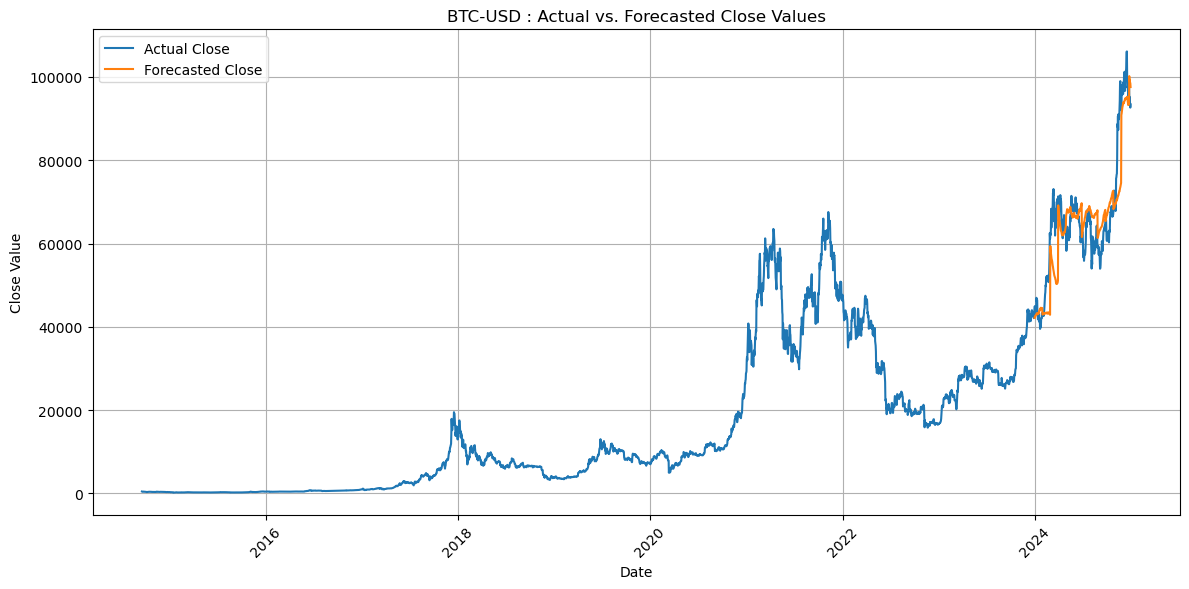

Evaluation Metric for BTC-USD_timesfm_30
MAPE: 8.656919239959219
ME: 1181.6968280396175
MAE: 5763.391329405737
MPE: 0.9923986841218863
RMSE: 7723.288780875668
R: 0.8564529098038081
Scalar Product: 12408091.238891602
Return Score: 0.5095890410958904
Long Return: 0.6210526315789474
Short Return: 0.38857142857142857
Mean Directional Accuracy: 0.5095890410958904
Mean Directional Accuracy Positive: 0.6210526315789474
Mean Directional Accuracy Negative: 0.38857142857142857


4731

In [38]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 30, freq='D', scaling = 's')
gc.collect()

afd57d3b-79b9-48c4-9e4d-f9e8a4093c4a


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=7, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 167.2130434513092 seconds


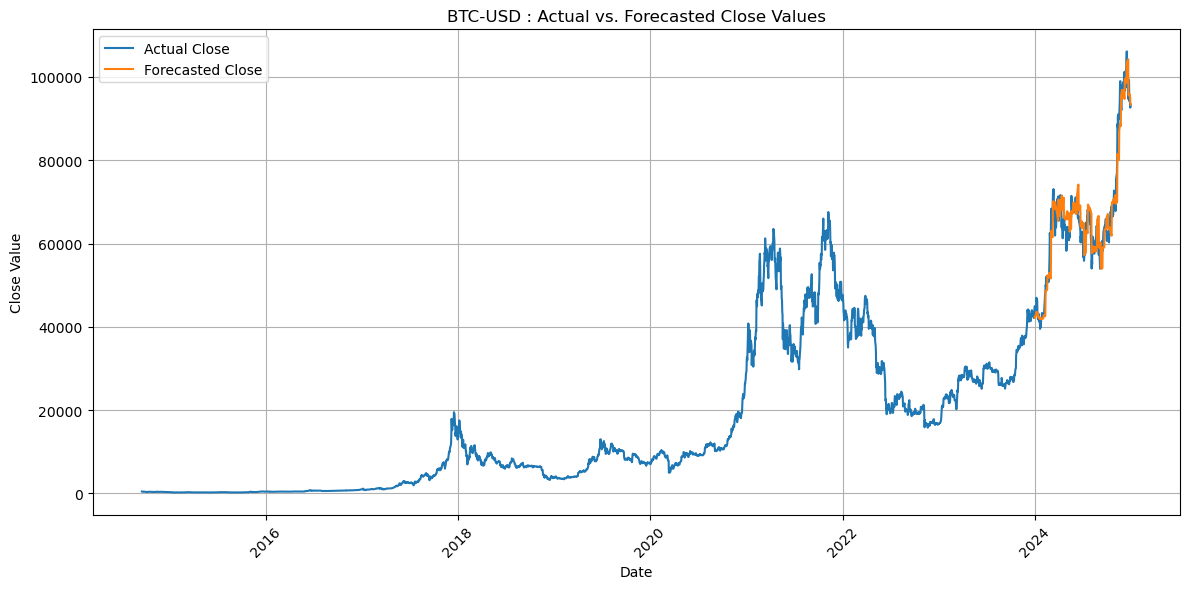

Evaluation Metric for BTC-USD_timesfm_7
MAPE: 5.008997847993746
ME: 75.6209656762295
MAE: 3295.1855575478144
MPE: -0.09387952227880708
RMSE: 4176.522455373584
R: 0.9588782120111031
Scalar Product: 175652370.65419006
Return Score: 0.4986301369863014
Long Return: 0.5421052631578948
Short Return: 0.4514285714285714
Mean Directional Accuracy: 0.4986301369863014
Mean Directional Accuracy Positive: 0.5421052631578948
Mean Directional Accuracy Negative: 0.4514285714285714


4348

In [39]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 7, freq='D', scaling = 's')
gc.collect()

995e61de-384f-4255-9fce-77a7b6d557bb


Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]


Model used: TimesFmHparams(context_len=512, horizon_len=1, input_patch_len=32, output_patch_len=128, num_layers=20, num_heads=16, model_dims=1280, per_core_batch_size=32, backend='gpu', quantiles=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9), use_positional_embedding=True, point_forecast_mode='median')
Execution time for forecast_crypto_prices(): 701.6905174255371 seconds


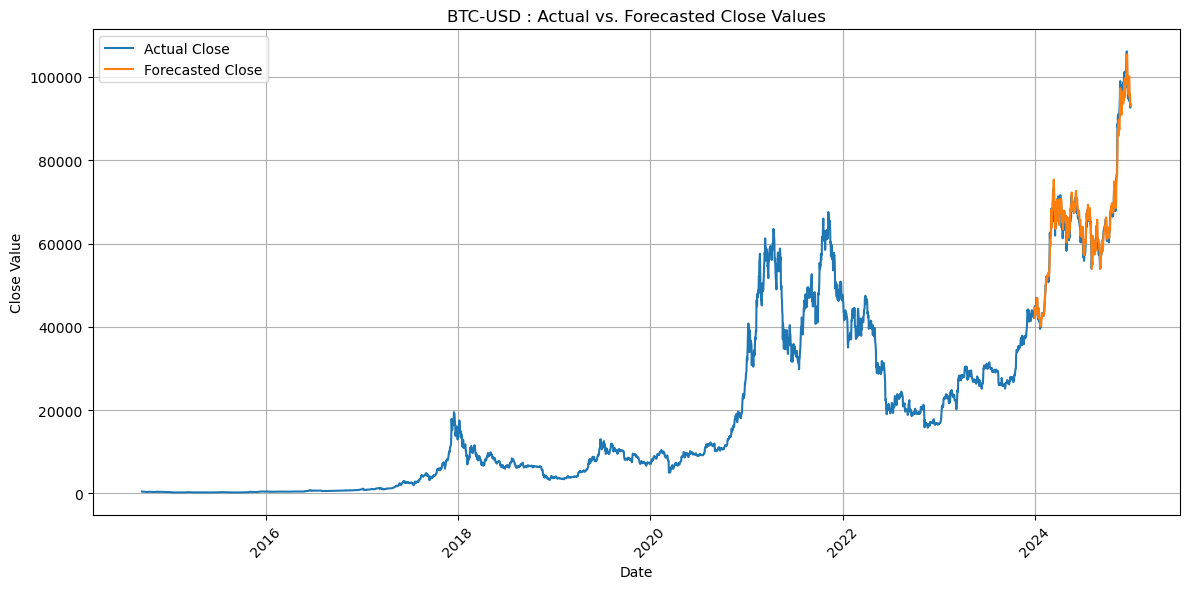

Evaluation Metric for BTC-USD_timesfm_1
MAPE: 2.5363781206404554
ME: -304.99057590505464
MAE: 1688.066566342213
MPE: -0.6222494609471307
RMSE: 2211.5858002691944
R: 0.9889290452074864
Scalar Product: -22486499.88241577
Return Score: 0.4876712328767123
Long Return: 0.5157894736842106
Short Return: 0.45714285714285713
Mean Directional Accuracy: 0.4876712328767123
Mean Directional Accuracy Positive: 0.5157894736842106
Mean Directional Accuracy Negative: 0.45714285714285713


4357

In [40]:
forecast_crypto_prices(crypto_symbols, data_dir, train_end_date="2023-12-31", horizon = 1, freq='D', scaling = 's')
gc.collect()